In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv


In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [4]:
train = pd.read_csv('/kaggle/input/datasets/ekowannanindome/stellar-dataset/train.csv', index_col='id')
test = pd.read_csv('/kaggle/input/datasets/ekowannanindome/stellar-dataset/test.csv', index_col='id')

print(f'Train: {train.shape} | Test: {test.shape}')
train.head()

Train: (577347, 11) | Test: (247435, 10)


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
id,,,,,,,,,,,
0,147.7343,16.9593,25.4721,21.8956,20.3579,19.2571,18.6211,0.4090,M,Red_Sequence,GALAXY
1,127.9887,32.3467,20.7785,19.0871,17.5872,17.2261,16.7864,0.1580,M,Red_Sequence,GALAXY
2,179.7926,35.3448,21.0352,21.0791,21.1718,20.5826,20.5574,2.8238,O/B,Blue_Cloud,QSO
3,225.8183,48.5694,23.3051,21.0507,19.0178,18.3657,17.9150,0.5361,M,Red_Sequence,GALAXY
4,141.8361,19.3429,21.7032,19.4717,18.2344,17.8994,17.6162,0.5558,M,Red_Sequence,GALAXY


## 2. Schema & Data Quality

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  object 
dtypes: float64(8), object(3)
memory usage: 52.9+ MB


In [6]:
# Null counts — train and test side by side
nulls = pd.DataFrame({
    'train_nulls': train.isnull().sum(),
    'train_%':     train.isnull().mean().mul(100).round(2),
    'test_nulls':  test.isnull().sum(),
    'test_%':      test.isnull().mean().mul(100).round(2),
})
nulls[nulls[['train_nulls', 'test_nulls']].sum(axis=1) > 0] if nulls[['train_nulls', 'test_nulls']].sum().sum() > 0 else print('No nulls found.')

No nulls found.


In [7]:
# Duplicate rows
print(f'Train duplicates: {train.duplicated().sum()}')
print(f'Test duplicates: {test.duplicated().sum()}')

Train duplicates: 0
Test duplicates: 0


In [8]:
train.describe()

,alpha,delta,u,g,r,i,z,redshift
count,577347.0000,577347.0000,577347.0000,577347.0000,577347.0000,577347.0000,577347.0000,577347.0000
mean,181.6167,21.8347,22.4419,21.0073,19.9628,19.3789,19.0411,0.7231
std,96.2429,18.9336,2.0181,1.7954,1.6490,1.5801,1.5844,0.8101
min,0.0117,-17.9670,-0.1392,13.5355,12.5794,11.9628,11.6828,-0.0100
25%,132.1615,2.4741,20.9771,19.8650,18.8207,18.3068,17.9732,0.1811
50%,188.6815,21.4844,22.5702,21.4678,20.4312,19.6316,19.1886,0.4975
75%,231.8297,36.9883,23.8691,22.2927,21.1641,20.6082,20.1621,0.8814
max,359.9998,79.1583,28.2533,27.6202,25.2545,27.9109,26.8269,7.0108


## 3. Target Distribution

         count       %
class                 
GALAXY  377480 65.3800
QSO     117143 20.2900
STAR     82724 14.3300


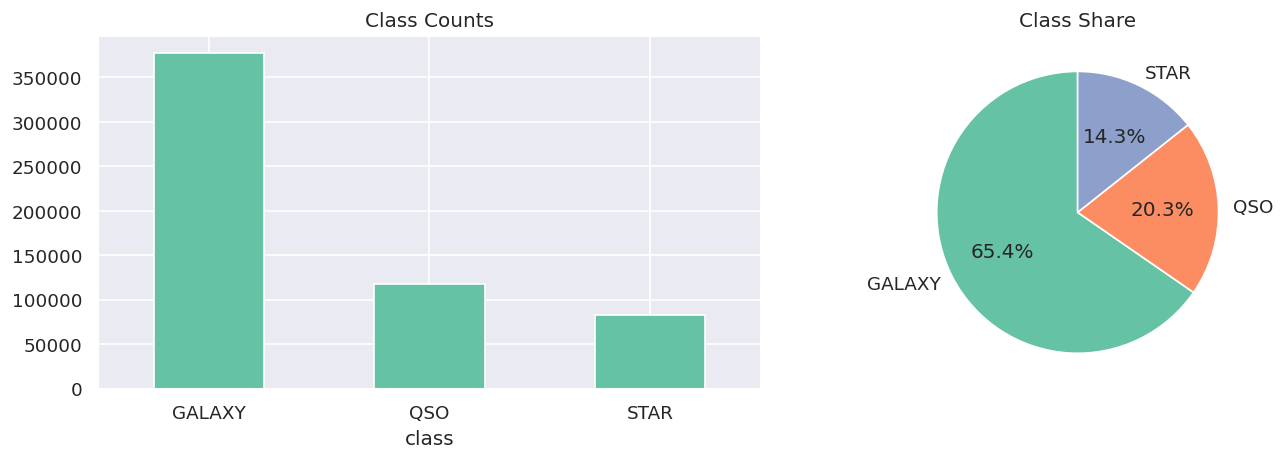

In [9]:
class_counts = train['class'].value_counts()
class_pct    = train['class'].value_counts(normalize=True).mul(100).round(2)

print(pd.DataFrame({'count': class_counts, '%': class_pct}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot.bar(ax=axes[0], title='Class Counts', rot=0)
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Share')
plt.tight_layout()

## 4. Categorical Features

In [11]:
cat_cols = ['spectral_type', 'galaxy_population']

for col in cat_cols:
    print(f'\n--- {col} ---')
    print(train[col].value_counts())


--- spectral_type ---
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

--- galaxy_population ---
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64


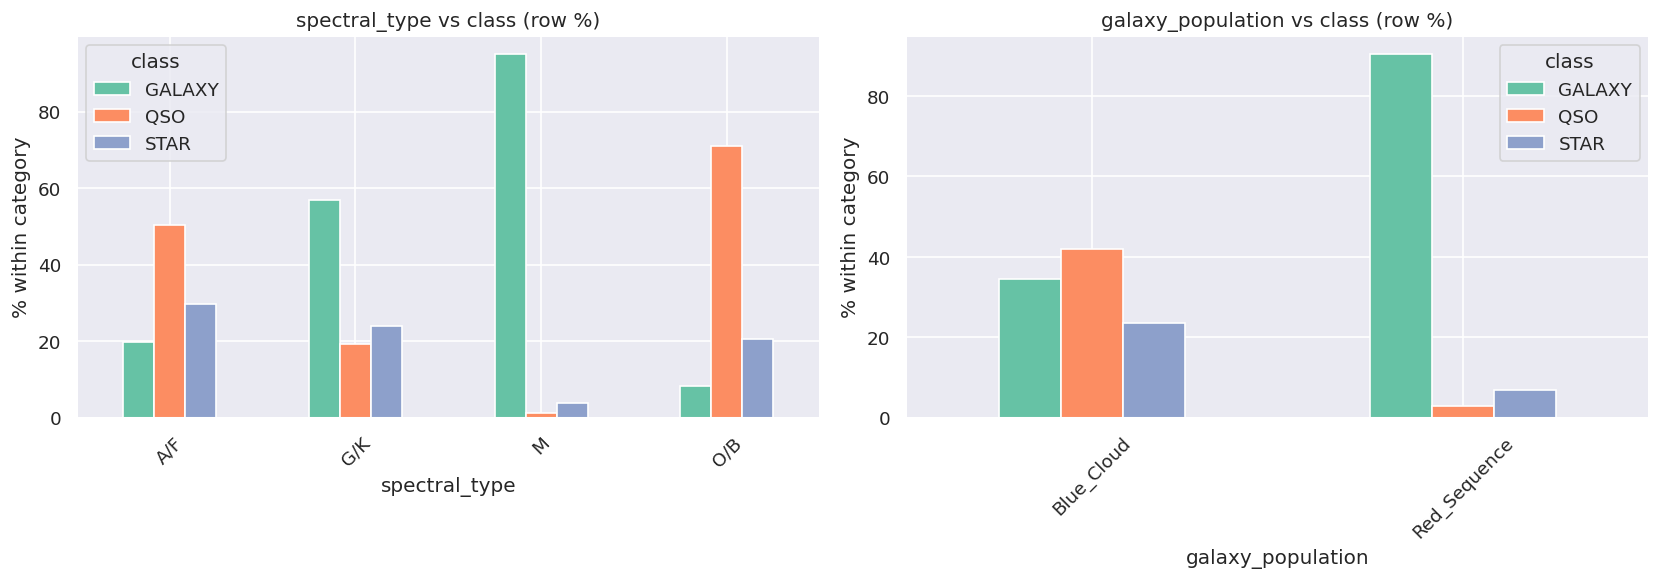

In [12]:
# How do categoricals interact with the target?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(train[col], train['class'], normalize='index').mul(100)
    ct.plot.bar(ax=ax, title=f'{col} vs class (row %)', rot=45)
    ax.set_ylabel('% within category')
    ax.legend(title='class')

plt.tight_layout()

## 5. Numerical Feature Distributions

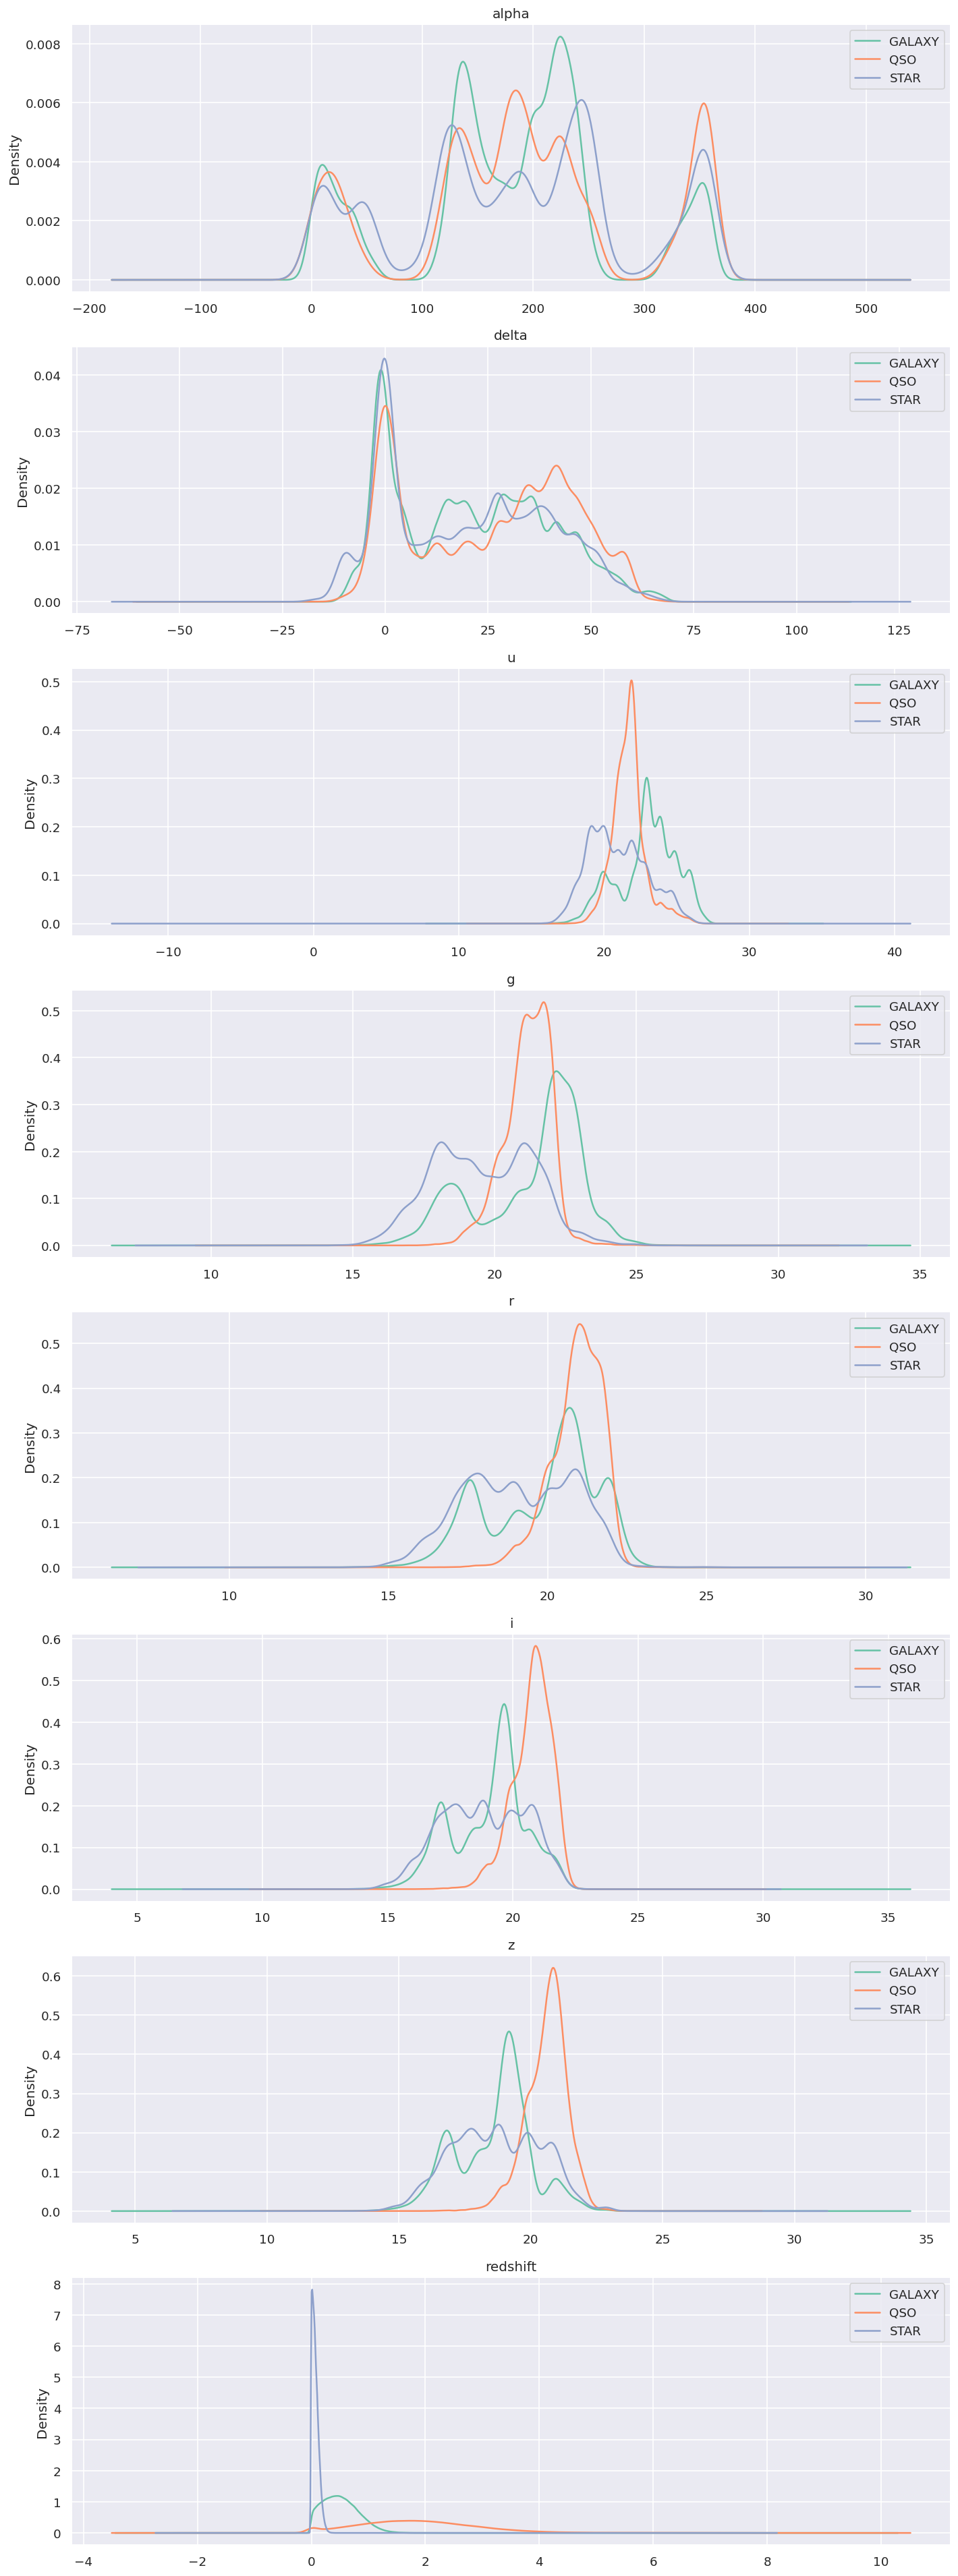

In [13]:
num_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
classes  = train['class'].unique()

fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 4 * len(num_cols)))

for ax, col in zip(axes, num_cols):
    for cls in classes:
        subset = train.loc[train['class'] == cls, col]
        subset.plot.kde(ax=ax, label=cls, linewidth=1.5)
    ax.set_title(col)
    ax.legend()
    ax.set_xlabel('')

plt.tight_layout()

## 6. Redshift Deep Dive

Redshift is the single strongest discriminator — QSOs typically have very high redshift.

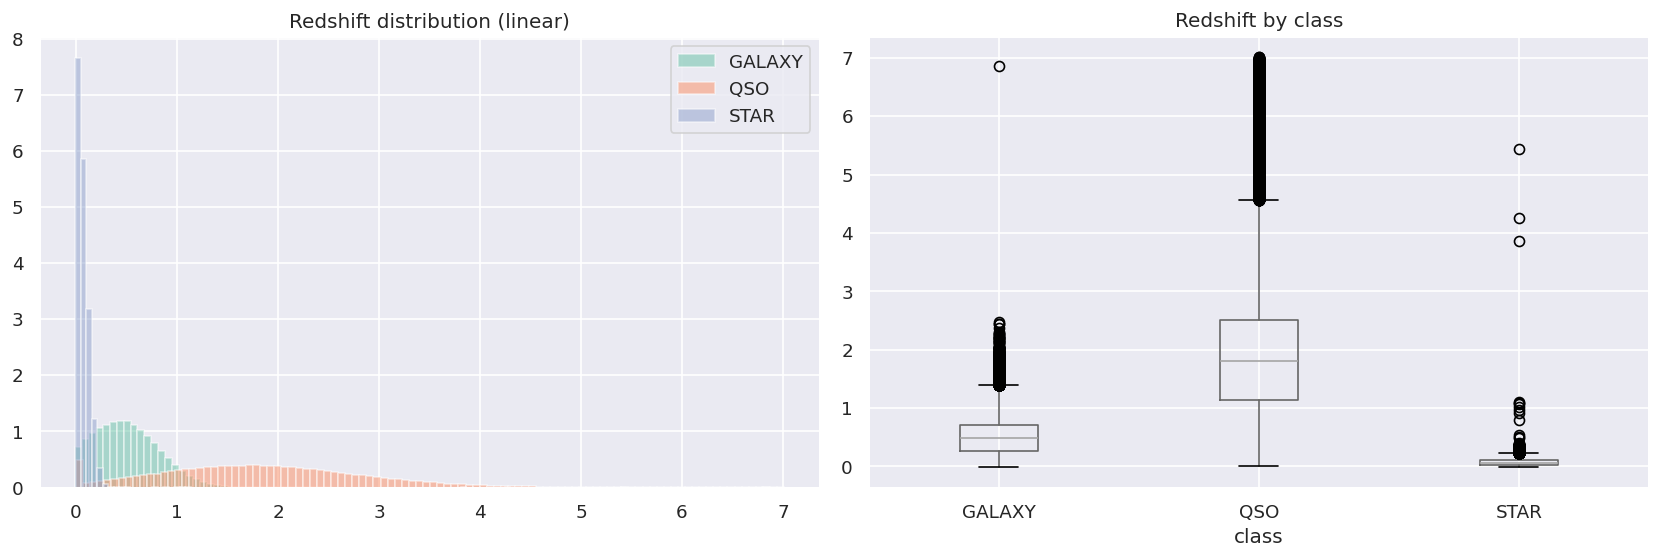

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
for cls in classes:
    subset = train.loc[train['class'] == cls, 'redshift']
    axes[0].hist(subset, bins=100, alpha=0.5, label=cls, density=True)
axes[0].set_title('Redshift distribution (linear)')
axes[0].legend()

# Box plot
train.boxplot(column='redshift', by='class', ax=axes[1])
axes[1].set_title('Redshift by class')
plt.suptitle('')
plt.tight_layout()

In [15]:
# Redshift summary stats per class
train.groupby('class')['redshift'].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.0000,0.5090,0.3091,-0.0099,0.2670,0.4820,0.7150,6.8603
QSO,117143.0000,1.8756,1.0697,0.0001,1.1318,1.7989,2.5064,7.0108
STAR,82724.0000,0.0681,0.0645,-0.0100,0.0219,0.0565,0.1021,5.4452


## 7. Photometric Color Indices

In astronomy, **color indices** (magnitude differences between filter bands) are the standard features for object classification.  
These differences cancel out distance-dependent brightness, leaving only spectral shape.

In [16]:
def add_colors(df):
    df = df.copy()
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['g_i'] = df['g'] - df['i']
    df['g_z'] = df['g'] - df['z']
    return df

train_c = add_colors(train)
color_cols = ['u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'g_z']

print('Color index stats:')
train_c[color_cols].describe().round(3)

Color index stats:


,u_g,g_r,r_i,i_z,u_r,g_i,g_z
count,577347.0000,577347.0000,577347.0000,577347.0000,577347.0000,577347.0000,577347.0000
mean,1.4350,1.0440,0.5840,0.3380,2.4790,1.6280,1.9660
std,1.1420,0.7360,0.4970,0.3960,1.5500,1.0740,1.2530
min,-23.1560,-8.1040,-10.7580,-14.2110,-21.5700,-10.8080,-12.7360
25%,0.5990,0.4200,0.2160,0.0940,1.2010,0.6350,0.7940
50%,1.3330,1.0760,0.5700,0.3440,2.4550,1.6820,2.0450
75%,2.0880,1.6460,0.9470,0.5900,3.5240,2.5510,3.0290
max,7.5230,8.8740,8.7490,7.6250,9.4020,9.2850,7.7540


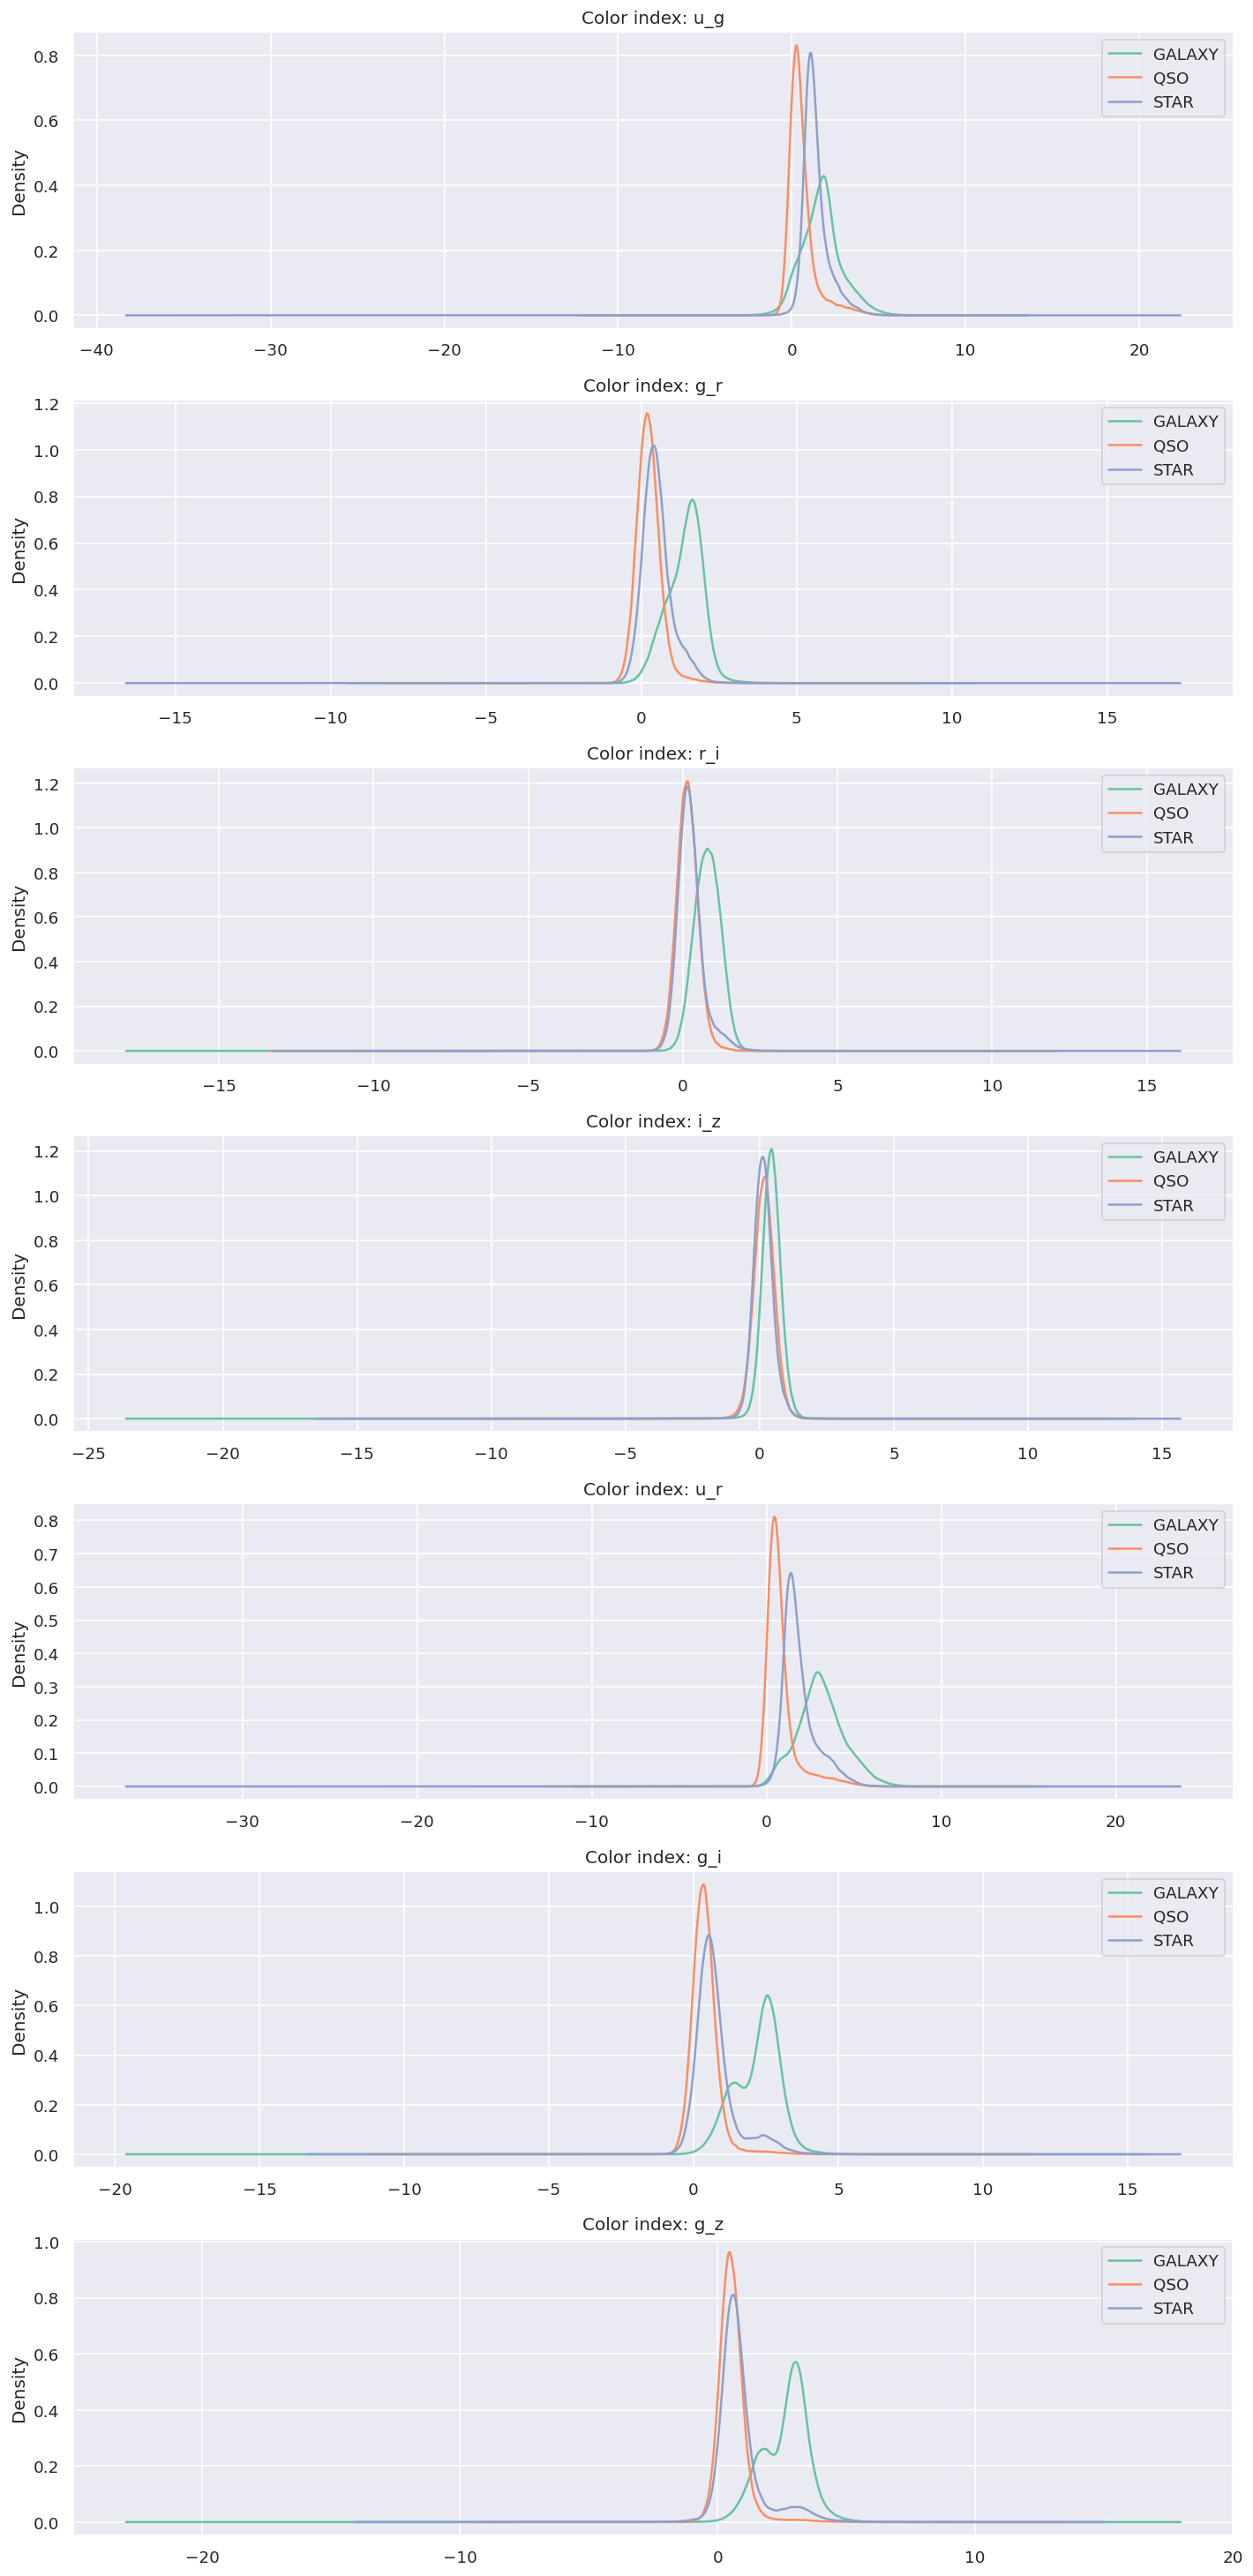

In [17]:
fig, axes = plt.subplots(len(color_cols), 1, figsize=(12, 3.5 * len(color_cols)))

for ax, col in zip(axes, color_cols):
    for cls in classes:
        subset = train_c.loc[train_c['class'] == cls, col]
        subset.plot.kde(ax=ax, label=cls, linewidth=1.5)
    ax.set_title(f'Color index: {col}')
    ax.legend()

plt.tight_layout()

## 8. Color-Color Diagrams

The canonical astronomy diagnostic: plot two color indices against each other. Stars, galaxies, and QSOs occupy distinct loci.

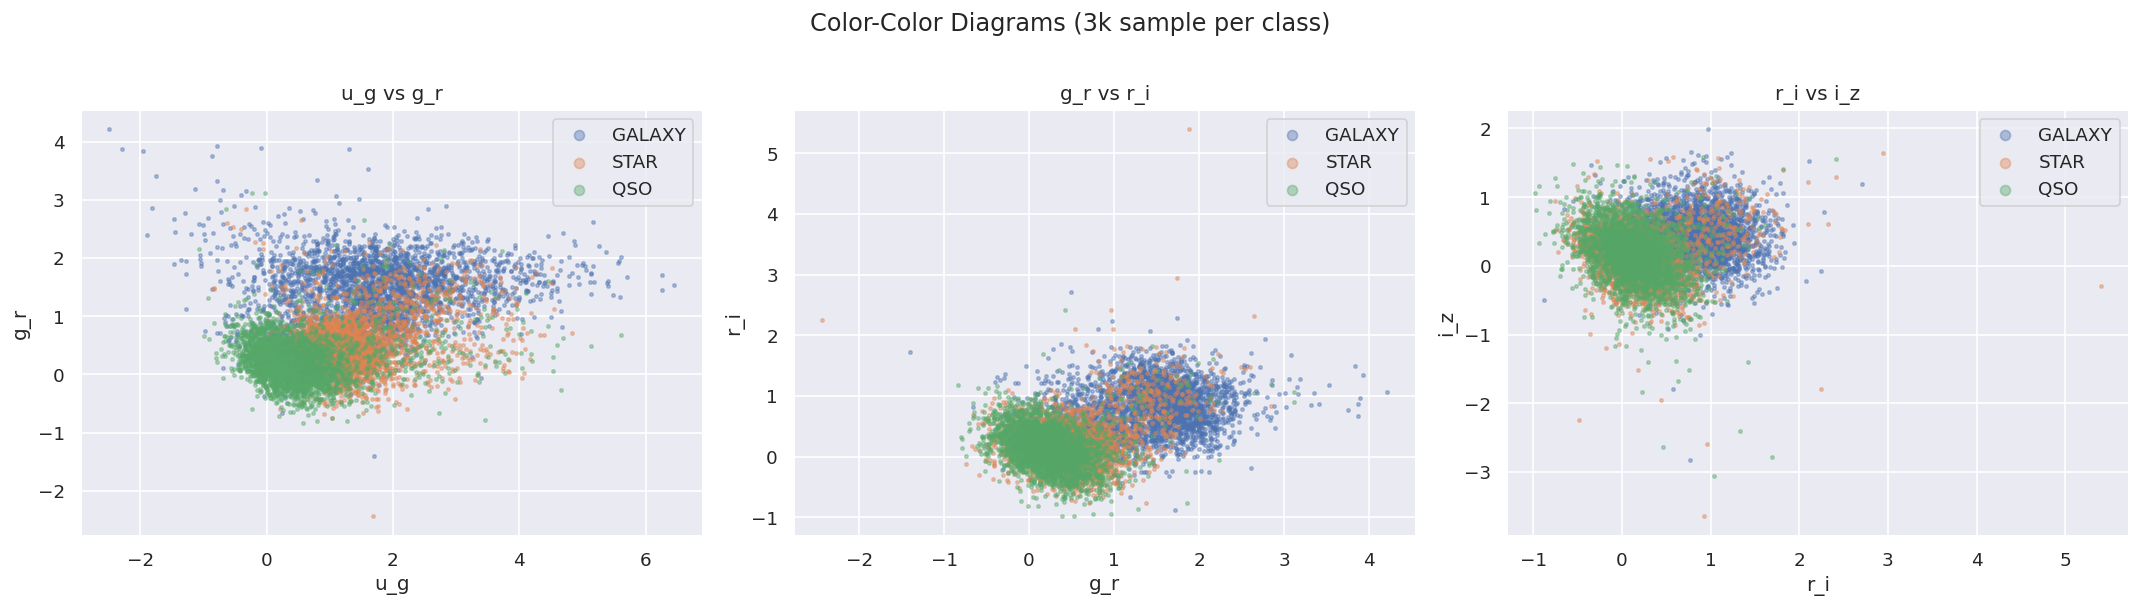

In [18]:
sample = train_c.groupby('class', group_keys=False).sample(n=3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [('u_g', 'g_r'), ('g_r', 'r_i'), ('r_i', 'i_z')]
palette = {'GALAXY': '#4c72b0', 'STAR': '#dd8452', 'QSO': '#55a868'}

for ax, (x, y) in zip(axes, pairs):
    for cls, color in palette.items():
        mask = sample['class'] == cls
        ax.scatter(sample.loc[mask, x], sample.loc[mask, y],
                   s=4, alpha=0.4, label=cls, color=color)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
    ax.legend(markerscale=3)

plt.suptitle('Color-Color Diagrams (3k sample per class)', y=1.01)
plt.tight_layout()

## 9. Correlation Matrix

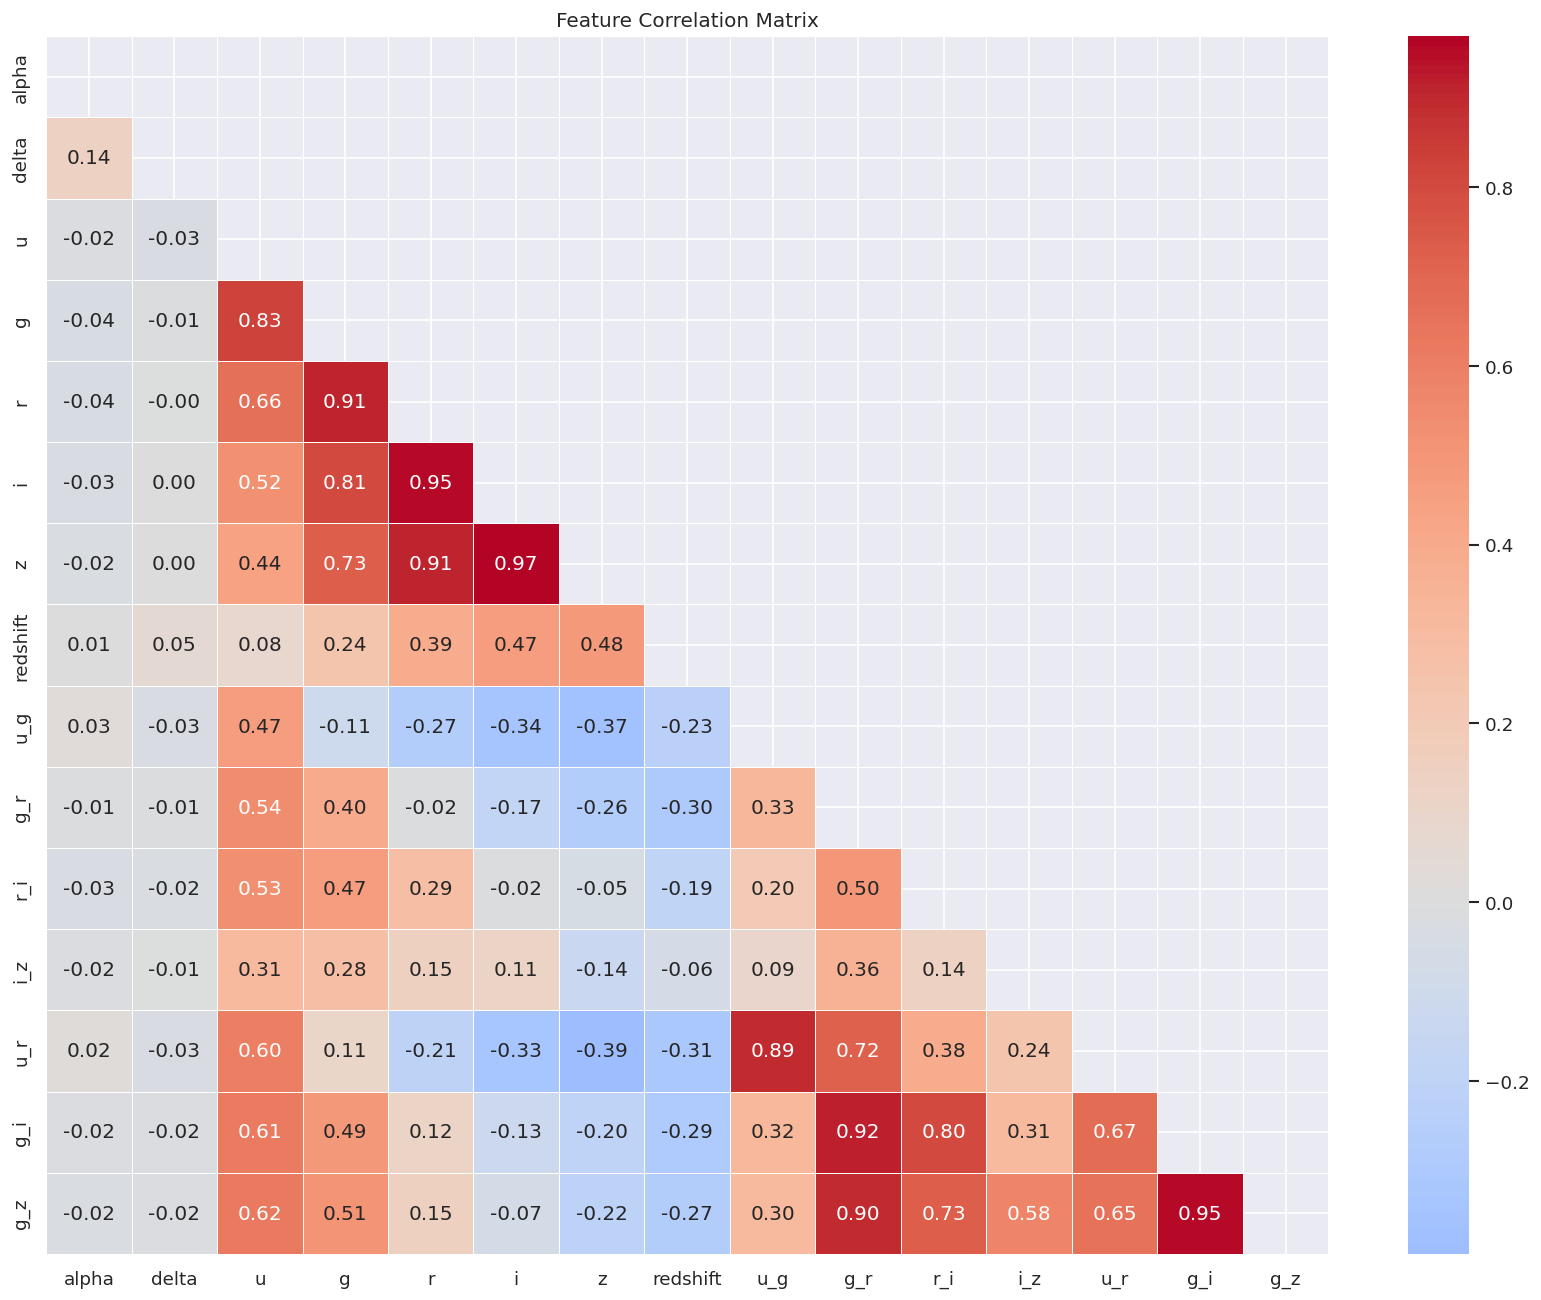

In [19]:
all_num = num_cols + color_cols
corr = train_c[all_num].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()

## 10. Train vs Test Distribution Check

Verify there's no significant distribution shift between train and test.

In [20]:
# KS test: small p-value = significant shift
ks_results = []
for col in num_cols:
    stat, p = stats.ks_2samp(train[col].dropna(), test[col].dropna())
    ks_results.append({'feature': col, 'ks_stat': stat, 'p_value': p})

ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)
print(ks_df.to_string(index=False))

 feature  ks_stat  p_value
       z   0.0028   0.1434
       i   0.0024   0.2609
redshift   0.0023   0.3343
   alpha   0.0021   0.4353
       g   0.0018   0.6548
       r   0.0017   0.7159
   delta   0.0014   0.8982
       u   0.0009   0.9994


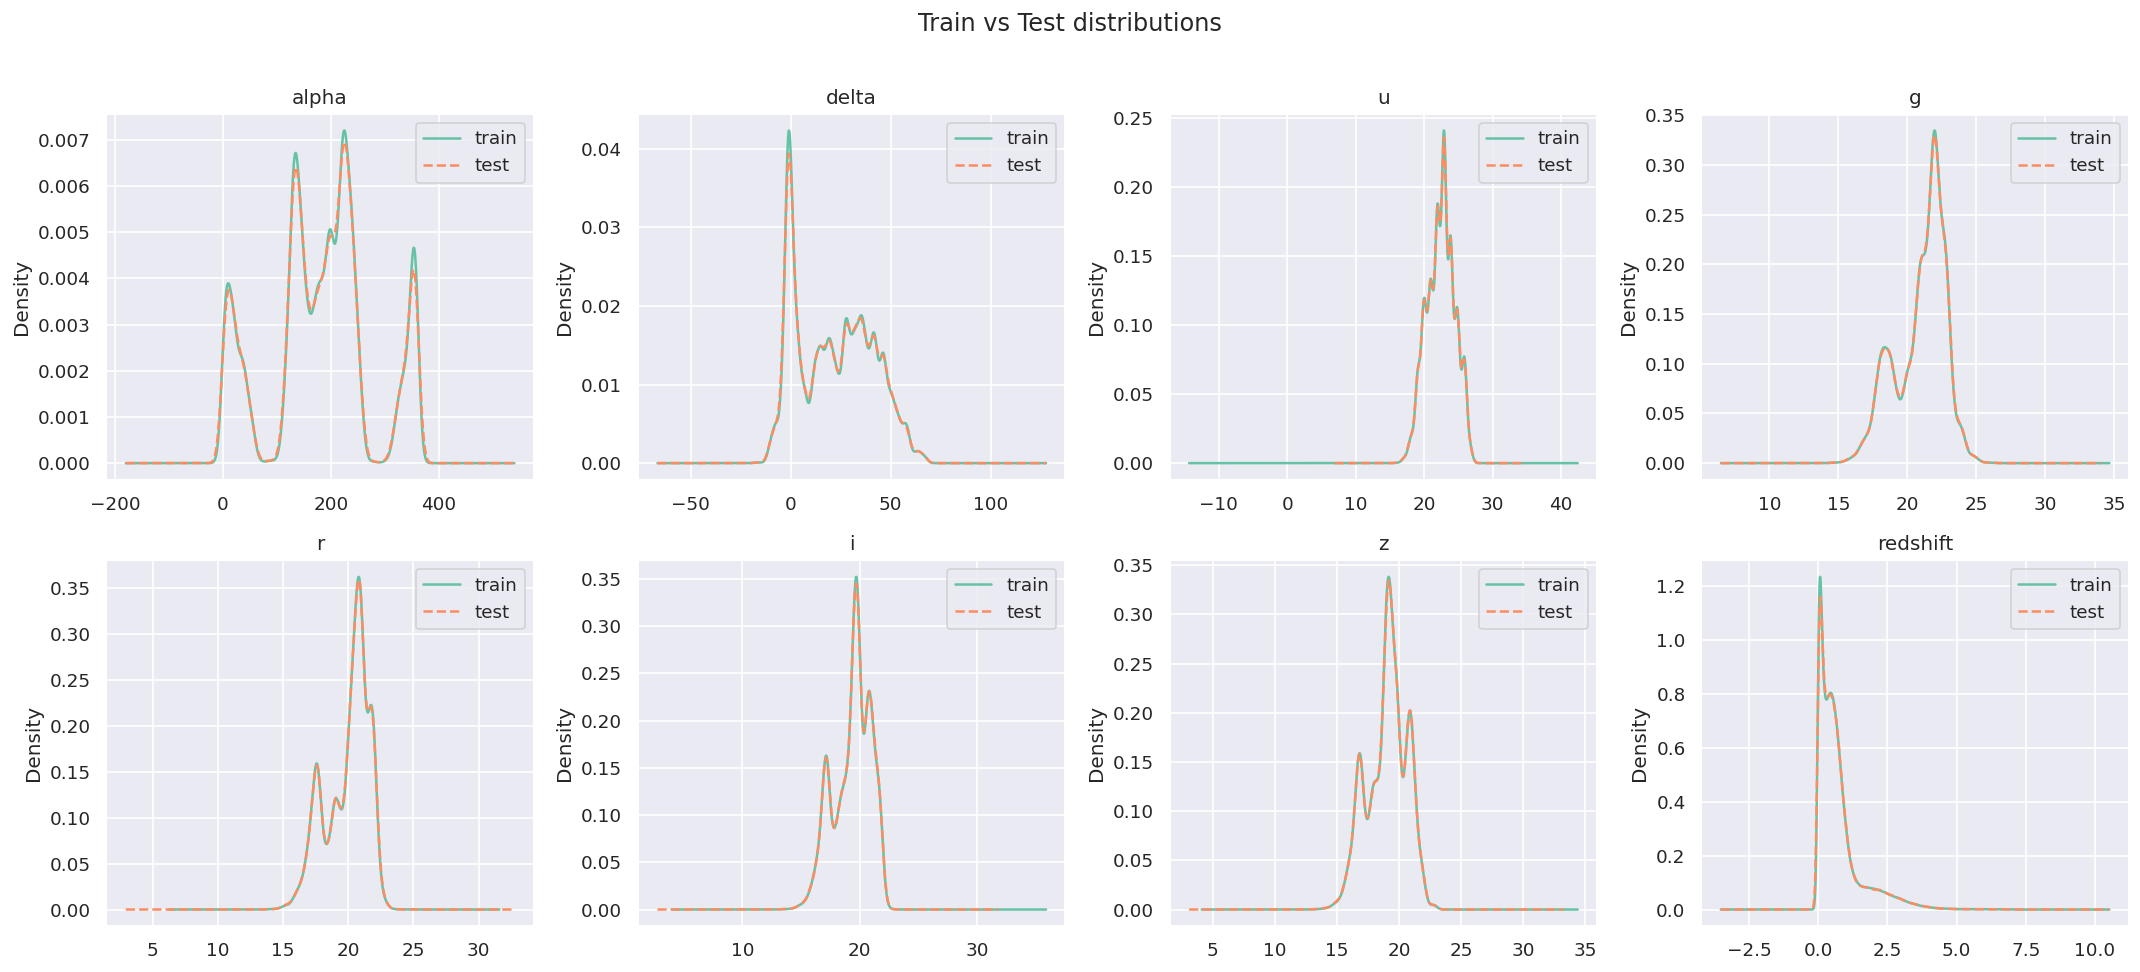

In [21]:
# Visual: overlaid density for each numerical feature
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    train[col].plot.kde(ax=ax, label='train', linewidth=1.5)
    test[col].plot.kde(ax=ax, label='test',  linewidth=1.5, linestyle='--')
    ax.set_title(col)
    ax.legend()

plt.suptitle('Train vs Test distributions', y=1.01)
plt.tight_layout()